Ejercicio 1:

Recorta el punto de interés de la imagenP.jpg tal cual se muestra en la figura, guarda la imagen recortada en tu disco local, y muestra la imagen recortada con axis (imagen a colores)

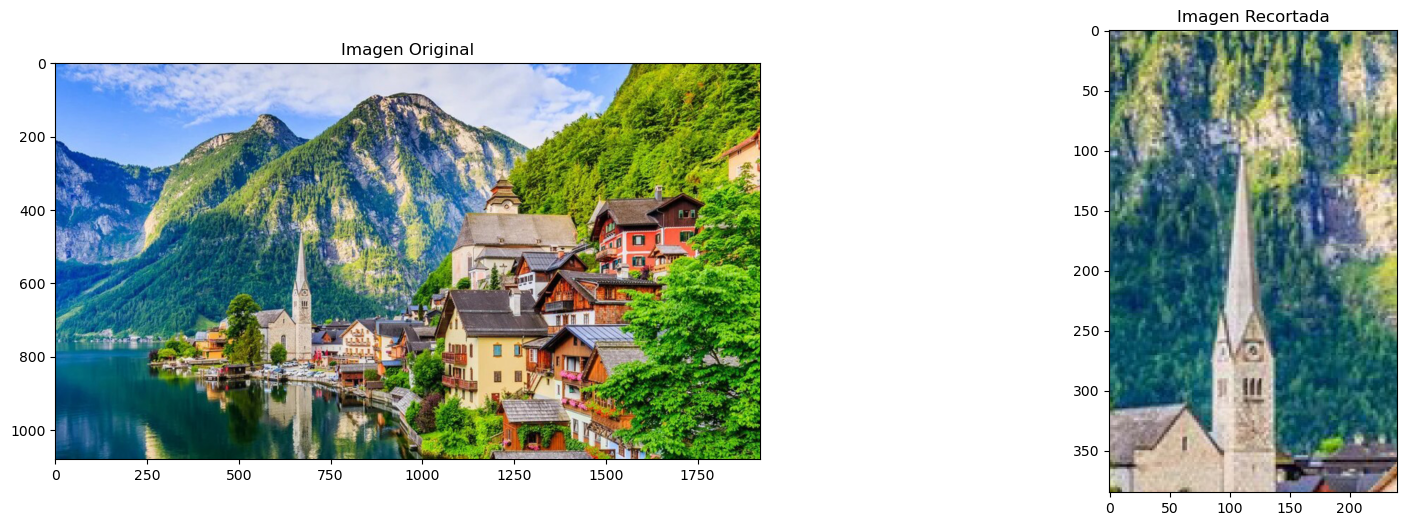

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagenP.jpg.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')

recortado_rgb = img_rgb[360:745, 560:800]
axs[1].imshow(recortado_rgb)
axs[1].set_title('Imagen Recortada')

plt.savefig('Imagen Recortada.png')
plt.show()

Ejercicio 2:

Genera un degradado lineal a colores (debe coincidir con los mismos colores).

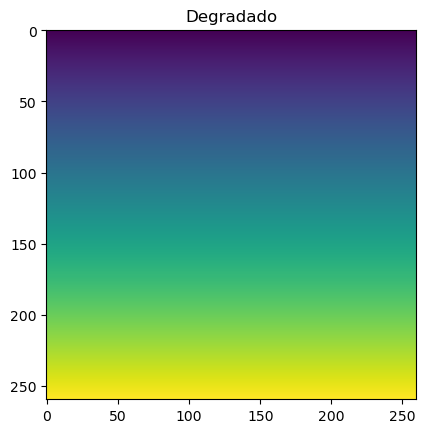

In [21]:
import numpy as np
import matplotlib.pyplot as plt

degradado = np.linspace(0, 1, 260) 
imagen = np.zeros((260, 260))

for i in range(260):
    imagen[:, i] = degradado

plt.imshow(imagen, cmap='viridis')
plt.title("Degradado")
plt.axis('on')
plt.savefig('degradado.png')
plt.show()


Ejercicio 3:

Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir 100x100 px

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


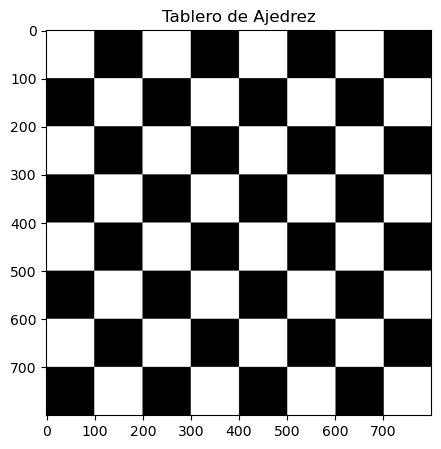

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

# Tablero
size_cuadrante = 100
size_total = size_cuadrante * 8
imagen = np.zeros((size_total, size_total, 3))

for i in range(8):
    for j in range(8):
        for x in range(size_cuadrante):
            for y in range(size_cuadrante):
                if (i + j) % 2 == 0:
                    # blanco
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = [255, 255, 255]
                else:
                    # negro
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = [0, 0, 0]

imagen_completa = np.array(imagen, dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('Tablero de Ajedrez')
plt.axis('on')
plt.savefig('tablero_ajedrez.png')
plt.show()

Ejercicio 4:

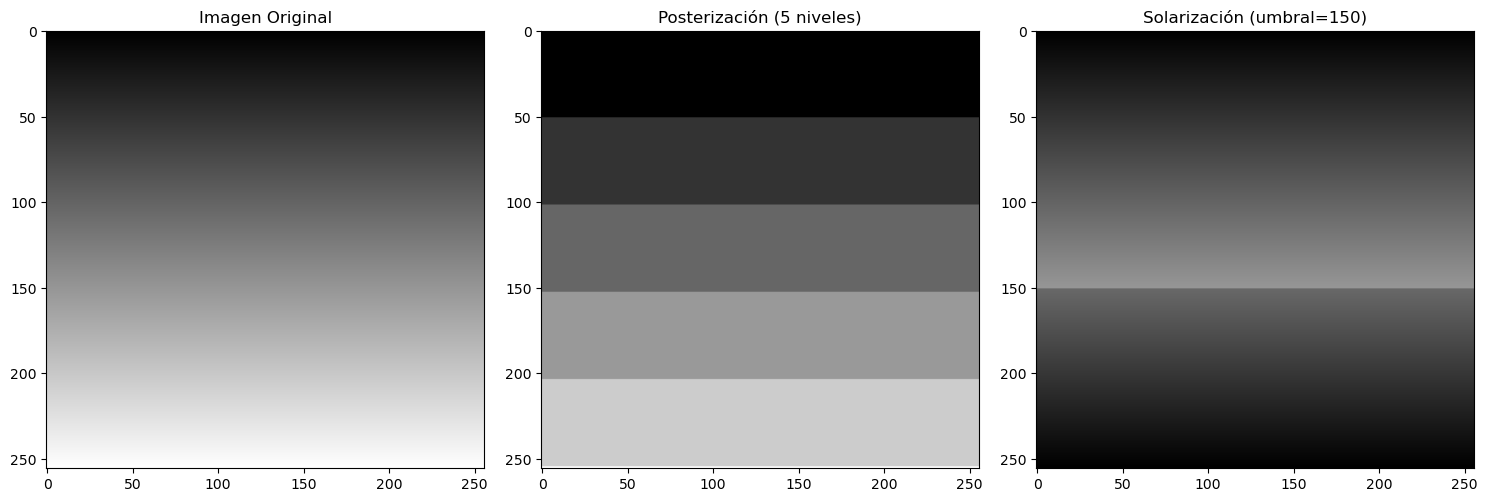

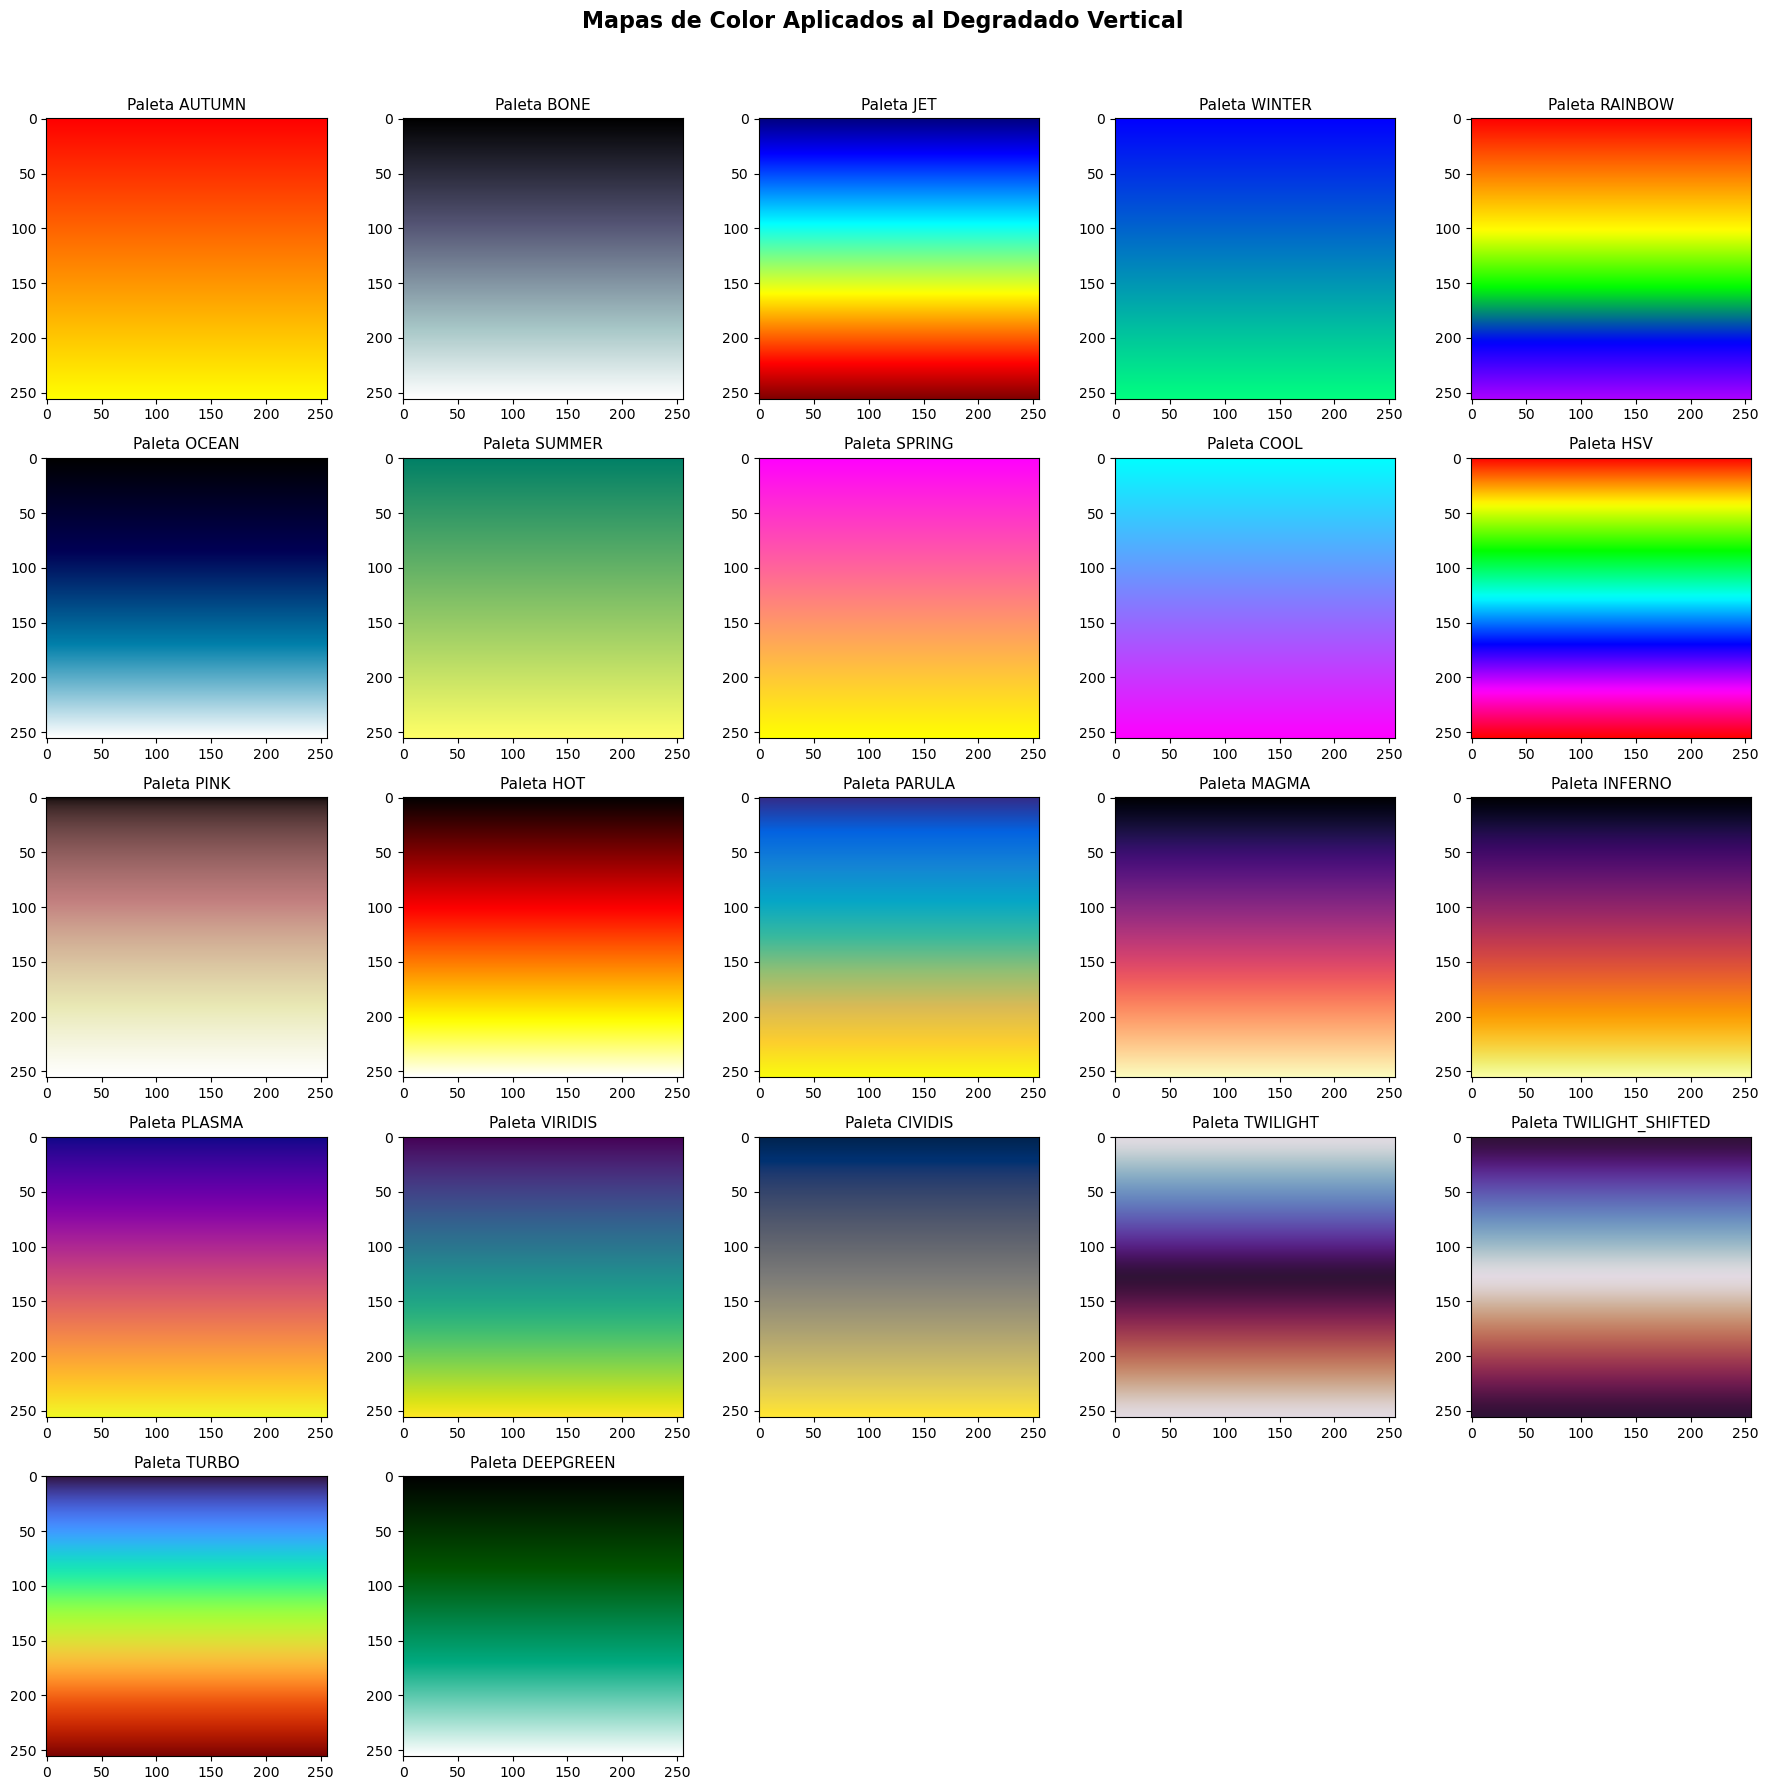

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Degradado del ejercicio 2
degradado = np.zeros((256, 256), dtype=np.uint8)
for i in range(256):
    degradado[i, :] = i
degradado_rgb = cv2.cvtColor(cv2.cvtColor(degradado, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2RGB)

# 1. POSTERIZACIÓN
niveles = 5  
factor = 256 // niveles
posterizado = (degradado // factor) * factor
posterizado_rgb = cv2.cvtColor(cv2.cvtColor(posterizado, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2RGB)

# 2. SOLARIZACIÓN
umbral = 150  
solarizado = degradado.copy()
solarizado[solarizado > umbral] = 255 - solarizado[solarizado > umbral]
solarizado_rgb = cv2.cvtColor(cv2.cvtColor(solarizado, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2RGB)

# Guardar la primera figura (Original, Posterizado, Solarizado)
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(degradado_rgb, cmap='gray')
axes[0].set_title('Imagen Original', fontsize=12)
axes[1].imshow(posterizado_rgb, cmap='gray')
axes[1].set_title(f'Posterización ({niveles} niveles)', fontsize=12)
axes[2].imshow(solarizado_rgb, cmap='gray')
axes[2].set_title(f'Solarización (umbral={umbral})', fontsize=12)
for ax in axes:
    ax.axis('on')
plt.tight_layout()
plt.savefig('ej4_procesamientos_basicos.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. PALETAS DE FALSO COLOR
colormaps = {
    'AUTUMN': cv2.COLORMAP_AUTUMN,
    'BONE': cv2.COLORMAP_BONE,
    'JET': cv2.COLORMAP_JET,
    'WINTER': cv2.COLORMAP_WINTER,
    'RAINBOW': cv2.COLORMAP_RAINBOW,
    'OCEAN': cv2.COLORMAP_OCEAN,
    'SUMMER': cv2.COLORMAP_SUMMER,
    'SPRING': cv2.COLORMAP_SPRING,
    'COOL': cv2.COLORMAP_COOL,
    'HSV': cv2.COLORMAP_HSV,
    'PINK': cv2.COLORMAP_PINK,
    'HOT': cv2.COLORMAP_HOT,
    'PARULA': cv2.COLORMAP_PARULA,
    'MAGMA': cv2.COLORMAP_MAGMA,
    'INFERNO': cv2.COLORMAP_INFERNO,
    'PLASMA': cv2.COLORMAP_PLASMA,
    'VIRIDIS': cv2.COLORMAP_VIRIDIS,
    'CIVIDIS': cv2.COLORMAP_CIVIDIS,
    'TWILIGHT': cv2.COLORMAP_TWILIGHT,
    'TWILIGHT_SHIFTED': cv2.COLORMAP_TWILIGHT_SHIFTED,
    'TURBO': cv2.COLORMAP_TURBO,
    'DEEPGREEN': cv2.COLORMAP_DEEPGREEN,
}

n_maps = len(colormaps)
cols = 5  
filas = (n_maps + cols - 1) // cols

fig, axes = plt.subplots(filas, cols, figsize=(18, filas * 3.5))
axes = axes.flatten()

for i, (nombre, cmap) in enumerate(colormaps.items()):
    falso_color = cv2.applyColorMap(degradado, cmap)
    falso_color_rgb = cv2.cvtColor(falso_color, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(falso_color_rgb)
    axes[i].set_title(f'Paleta {nombre}', fontsize=11)
    axes[i].axis('on')
    
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Mapas de Color Aplicados al Degradado Vertical', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ej4_paletas_falso_color.png', dpi=300, bbox_inches='tight')
plt.show()

Ejercicio 5:

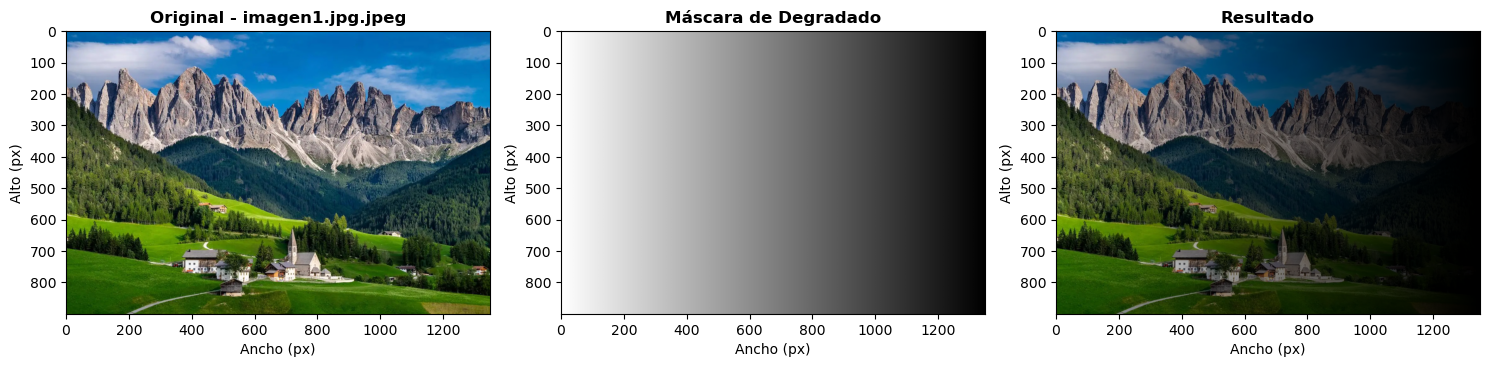

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Cargar imagen
imagen = cv2.imread('imagen1.jpg.jpeg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
alto, ancho = imagen.shape[:2]

# Crear máscara de degradado horizontal usando tu método
degradado = np.linspace(1.0, 0.0, ancho) 
mascara = np.zeros((alto, ancho))

for i in range(ancho):
    mascara[:, i] = degradado[i]

# Expandir a 3 canales
mascara_3ch = np.stack([mascara] * 3, axis=2)

# Aplicar degradado multiplicativo
resultado = (imagen_rgb.astype(np.float64) * mascara_3ch).astype(np.uint8)

# Guardar resultado individualmente
cv2.imwrite('ej5_degradado_lineal.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))

# Mostrar comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Original - imagen1.jpg.jpeg', fontweight='bold')

axes[1].imshow(mascara, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Máscara de Degradado', fontweight='bold')

axes[2].imshow(resultado)
axes[2].set_title('Resultado', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Ancho (px)')
    ax.set_ylabel('Alto (px)')

plt.tight_layout()
plt.savefig('ej5_comparacion_degradado.png', dpi=300, bbox_inches='tight')
plt.show()

Ejercicio 6:

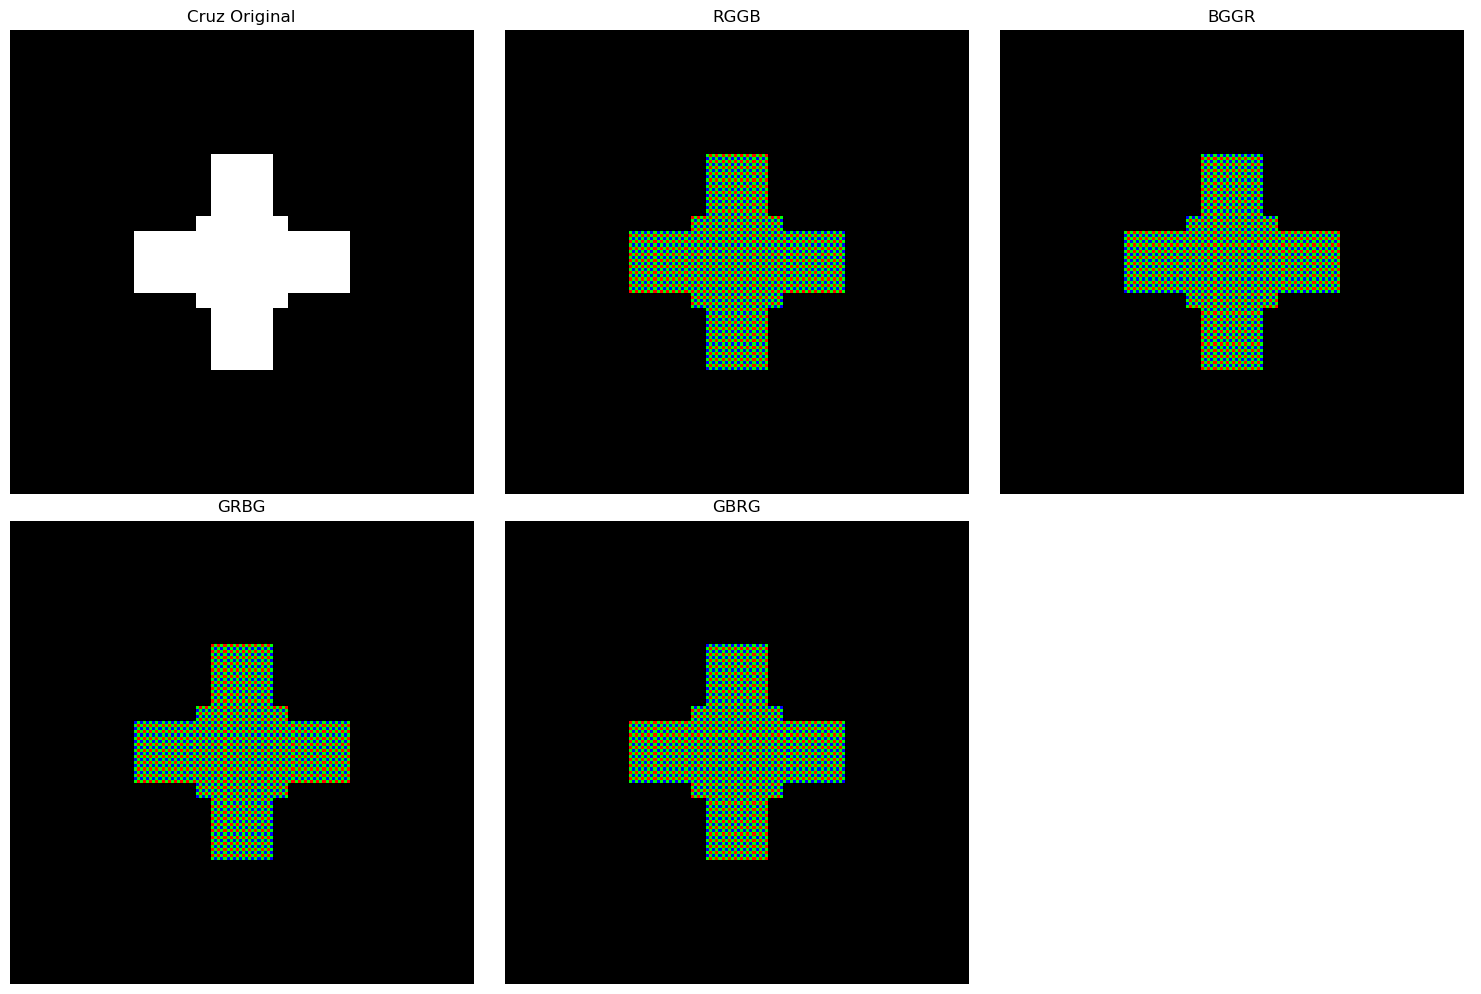

Imagen guardada como: ej6_cruz_bayer.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def crear_cruz():
    # Línea negra
    cruz = np.zeros((150, 150, 3), dtype=np.uint8)
    
    # Línea vertical 
    cruz[40:110, 65:85] = [255, 255, 255]
    
    # Línea horizontal 
    cruz[65:85, 40:110] = [255, 255, 255]
    
    # Centro
    cruz[60:90, 60:90] = [255, 255, 255]
    
    return cruz


def separar_canales(imagen):
    return imagen[:, :, 0], imagen[:, :, 1], imagen[:, :, 2]


def aplicar_bayer(rojo, verde, azul, patron):
    alto, ancho = rojo.shape
    resultado = np.zeros((alto, ancho, 3), dtype=np.uint8)
    
    if patron == "RGGB":
        resultado[0::2, 0::2, 0] = rojo[0::2, 0::2]      # R
        resultado[0::2, 1::2, 1] = verde[0::2, 1::2]    # G
        resultado[1::2, 0::2, 1] = verde[1::2, 0::2]    # G
        resultado[1::2, 1::2, 2] = azul[1::2, 1::2]      # B
    
    elif patron == "BGGR":
        resultado[0::2, 0::2, 2] = azul[0::2, 0::2]      # B
        resultado[0::2, 1::2, 1] = verde[0::2, 1::2]    # G
        resultado[1::2, 0::2, 1] = verde[1::2, 0::2]    # G
        resultado[1::2, 1::2, 0] = rojo[1::2, 1::2]      # R
    
    elif patron == "GRBG":
        resultado[0::2, 0::2, 1] = verde[0::2, 0::2]    # G
        resultado[0::2, 1::2, 0] = rojo[0::2, 1::2]      # R
        resultado[1::2, 0::2, 2] = azul[1::2, 0::2]      # B
        resultado[1::2, 1::2, 1] = verde[1::2, 1::2]    # G
    
    elif patron == "GBRG":
        resultado[0::2, 0::2, 1] = verde[0::2, 0::2]    # G
        resultado[0::2, 1::2, 2] = azul[0::2, 1::2]      # B
        resultado[1::2, 0::2, 0] = rojo[1::2, 0::2]      # R
        resultado[1::2, 1::2, 1] = verde[1::2, 1::2]    # G
    
    return resultado


# Crear imagen
imagen = crear_cruz()
rojo, verde, azul = separar_canales(imagen)

# Patrones
patrones = ["RGGB", "BGGR", "GRBG", "GBRG"]
resultados = {}

for patron in patrones:
    resultados[patron] = aplicar_bayer(rojo, verde, azul, patron)

# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(imagen)
axes[0,0].set_title('Cruz Original')
axes[0,0].axis('off')

axes[0,1].imshow(resultados["RGGB"])
axes[0,1].set_title('RGGB')
axes[0,1].axis('off')

axes[0,2].imshow(resultados["BGGR"])
axes[0,2].set_title('BGGR')
axes[0,2].axis('off')

axes[1,0].imshow(resultados["GRBG"])
axes[1,0].set_title('GRBG')
axes[1,0].axis('off')

axes[1,1].imshow(resultados["GBRG"])
axes[1,1].set_title('GBRG')
axes[1,1].axis('off')

axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('ej6_cruz_bayer.png', dpi=300, bbox_inches='tight')
plt.show()
